In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
sm=pd.read_csv(r"C:\Users\HITESH\Downloads\Market.csv\Market.csv")

In [7]:
sm.shape

(112457, 8)

In [8]:
sm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  object 
 1   Date       112457 non-null  object 
 2   Open       110253 non-null  float64
 3   High       110252 non-null  float64
 4   Low        110251 non-null  float64
 5   Close      110250 non-null  float64
 6   Adj Close  110244 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), object(2)
memory usage: 6.9+ MB


In [10]:
sm.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [14]:
print(sm.isnull().sum())

Index           0
Date            0
Open         2204
High         2205
Low          2206
Close        2207
Adj Close    2213
Volume       2204
dtype: int64


In [15]:
sm=sm.dropna()

In [17]:
Q1 = sm[['Open','High','Low','Close','Volume']].quantile(0.25)
Q3 = sm[['Open','High','Low','Close','Volume']].quantile(0.75)
IQR = Q3 - Q1
sm = sm[~((sm[['Open','High','Low','Close','Volume']] < (Q1 - 1.5 * IQR)) | 
              (sm[['Open','High','Low','Close','Volume']] > (Q3 + 1.5 * IQR))).any(axis=1)]

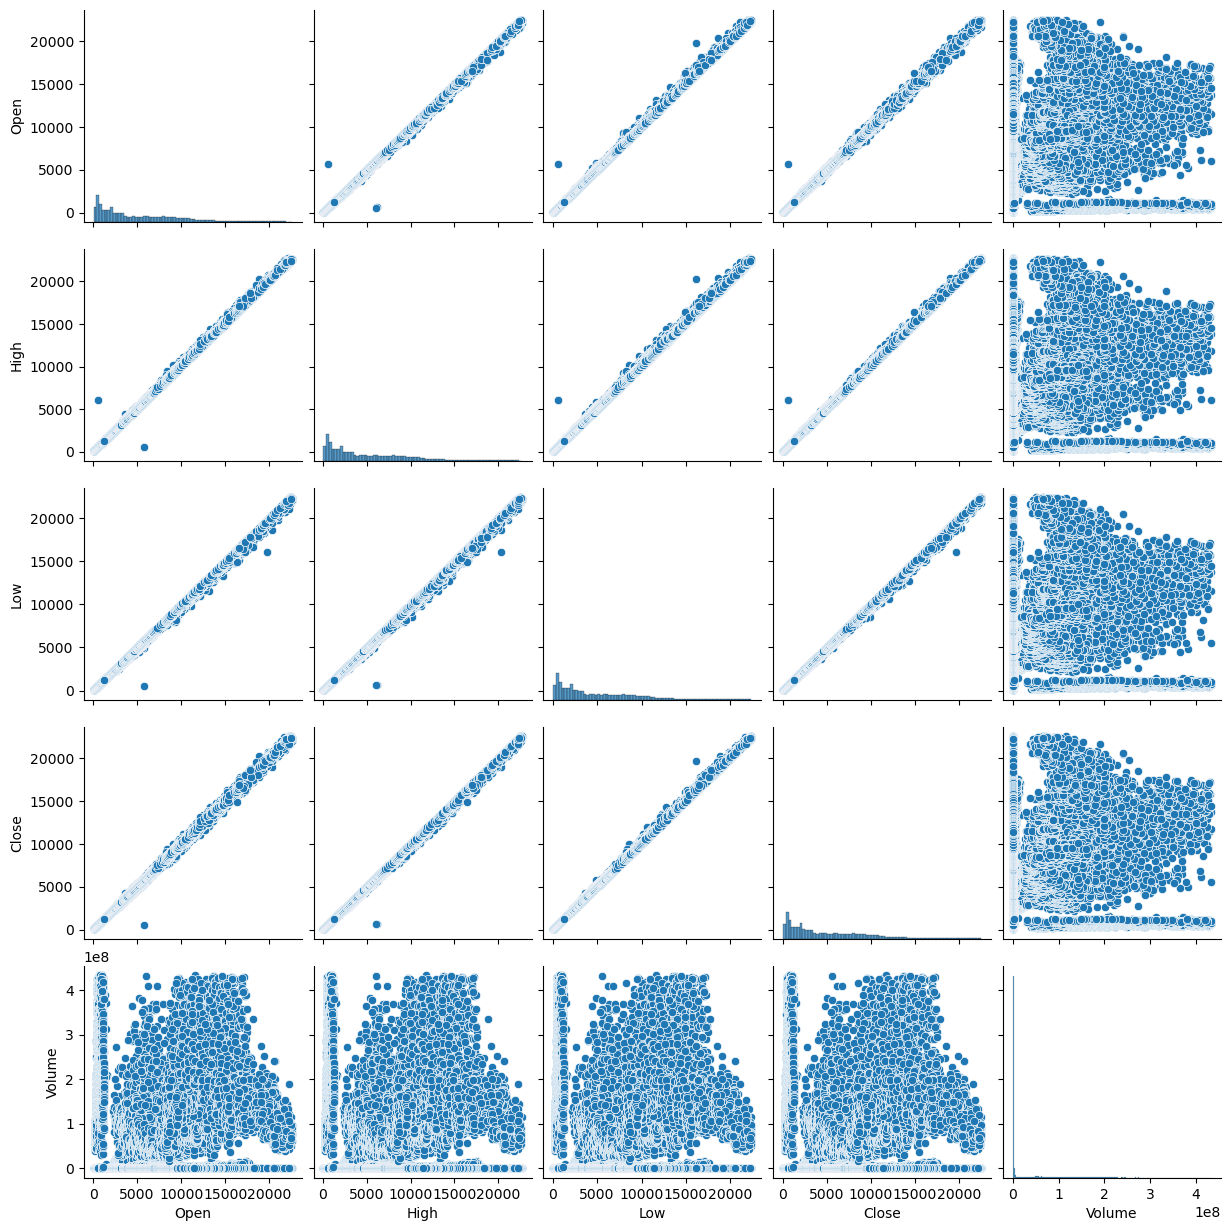

In [18]:
sns.pairplot(sm[['Open','High','Low','Close','Volume']])
plt.show()

In [19]:
X = sm[['Open','High','Low','Volume']]
y = sm['Close']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [21]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9999141764108075
RMSE: 45.39335757040281


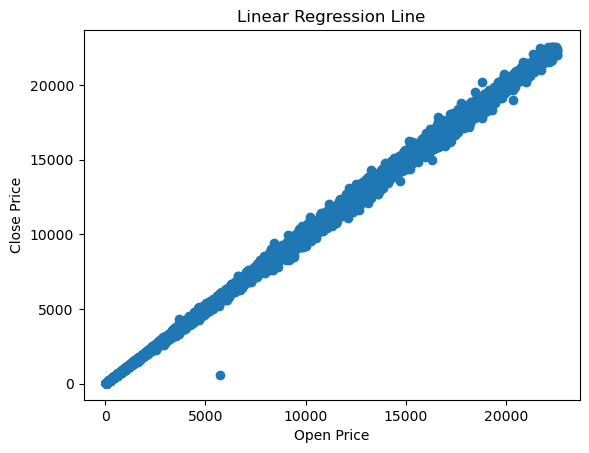

In [24]:
X = sm[['Open']]
y = sm['Close']
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)
plt.scatter(sm['Open'], sm['Close'])

plt.plot(sm['Open'], model.predict(X))

plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Linear Regression Line")

plt.show()

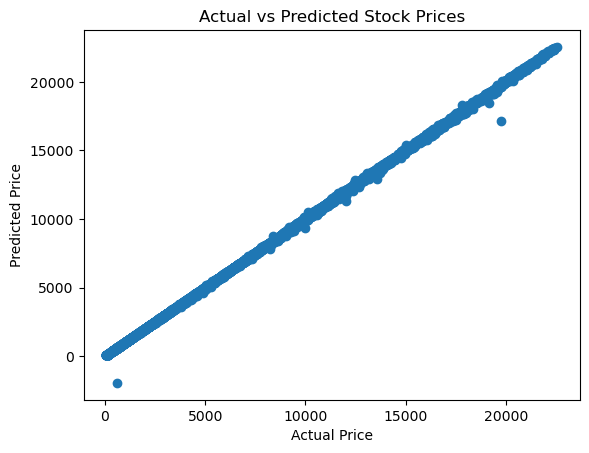

In [25]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Stock Prices")

plt.show()